In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [4]:
pd.set_option('display.max_columns',None)

In [5]:
path = '/Users/qianj/Library/Mobile Documents/com~apple~CloudDocs/AA_2024-2026 job/Erdos_Project'

In [33]:
df_origin = pd.read_csv(f'{path}/Modeling/common_NPI_pushed_year_df_with_pca_1_scaled_type_tot_risk_covid_11.csv').drop('Unnamed: 0', axis=1)

In [34]:
df_origin.columns

Index(['Rndrng_NPI', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_State_Abrvtn',
       'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'Tot_HCPCS_Cds',
       'Tot_Benes', 'Tot_Srvcs', 'Tot_Sbmtd_Chrg', 'Tot_Mdcr_Alowd_Amt',
       'Tot_Mdcr_Pymt_Amt', 'Bene_Avg_Age', 'Bene_Avg_Risk_Scre', 'pca_1',
       'Tot_Risk', 'APP_Tot_Risk', 'PrimaryCare_Tot_Risk',
       'MedicalSpecialtyOther_Tot_Risk', 'LabPathology_Tot_Risk',
       'PharmacyNutrition_Tot_Risk', 'state', 'Tot_Mdcr_Pymt_Amt_current',
       'current_year', 'Is_Covid'],
      dtype='object')

# Preprocessing Columns

In [35]:
label_cols = ['APP_Tot_Risk','PrimaryCare_Tot_Risk','MedicalSpecialtyOther_Tot_Risk','LabPathology_Tot_Risk','PharmacyNutrition_Tot_Risk']

def label_num_to_cat(df,cols):
    for c in cols:
        df[c] = df[c].astype(int).astype('object')
    return

In [36]:
label_num_to_cat(df_origin,label_cols)

In [37]:
from sklearn.preprocessing import OneHotEncoder

def enc_df(df):
    num_cols = df.select_dtypes(include='number').columns.tolist()
    # num_cols = [c for c in num_cols if c not in ['Tot_HCPCS_Cds', 'Tot_Mdcr_Pymt_Amt']]
    cat_cols = df.select_dtypes(exclude='number').columns.tolist()
    cat_cols = [c for c in cat_cols if c!='Rndrng_Prvdr_State_Abrvtn']

    cat_orders = []

    for c in cat_cols:
        cat_orders.append(df[c].unique().tolist())

    enc = OneHotEncoder(
        categories=cat_orders,
        handle_unknown='ignore',
        sparse_output=False,
        feature_name_combiner=lambda feature,category: f'{feature.split('_')[-1]}_{category}' if 'Rndrng' in feature else f'{feature}_{category}'
    )

    X_cat = enc.fit_transform(df[cat_cols])

    dummy_names = enc.get_feature_names_out(cat_cols)

    X_cat_df = pd.DataFrame(X_cat,columns=dummy_names,index=df.index)
    X = pd.concat([df[num_cols],X_cat_df],axis=1)
    return X


In [38]:
temp = enc_df(df_origin)
temp

,Rndrng_NPI,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Pymt_Amt,Bene_Avg_Age,Bene_Avg_Risk_Scre,pca_1,Tot_Risk,Tot_Mdcr_Pymt_Amt_current,current_year,Is_Covid,Cd_I,Cd_O,Type_PrimaryCare,Type_LabPathology,Type_Anesthesia,Type_OBGYN,Type_SurgeryOther,Type_CardioVascularSurgery,Type_APP,Type_Cardiology,Type_MedicalSpecialtyOther,Type_RehabTherapy,Type_FacilitySupplierProgram,Type_OncologyHeme,Type_RadiologyImaging,Type_AcuteCare,Type_BehavioralHealth,Type_VisionHearing,Type_PharmacyNutrition,Type_UnknownOther,Ind_Y,Ind_N,APP_Tot_Risk_2,APP_Tot_Risk_1,APP_Tot_Risk_0,PrimaryCare_Tot_Risk_0,PrimaryCare_Tot_Risk_2,PrimaryCare_Tot_Risk_1,MedicalSpecialtyOther_Tot_Risk_2,MedicalSpecialtyOther_Tot_Risk_0,MedicalSpecialtyOther_Tot_Risk_1,LabPathology_Tot_Risk_3,LabPathology_Tot_Risk_2,LabPathology_Tot_Risk_1,LabPathology_Tot_Risk_0,PharmacyNutrition_Tot_Risk_2,PharmacyNutrition_Tot_Risk_0,PharmacyNutrition_Tot_Risk_1,state_South,state_Midwest,state_Northeast,state_West,state_Territory,state_Military,state_Unknown
0,1003000126,22,665,1648.0,395335.0,146521.84,116332.66,74,2.1114,0.047429,1404.0810,194073.09,2014,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1003000134,13,3939,7517.0,1211425.0,282079.49,217960.62,76,1.0156,0.411904,4000.4484,245270.71,2014,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1003000142,42,144,661.0,197224.0,63334.30,49752.77,63,1.5662,-0.096087,225.5328,51820.04,2014,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1003000407,37,436,1683.0,240818.0,174786.95,138741.21,76,1.8967,0.037454,826.9612,85838.44,2014,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1003000423,33,63,320.0,31637.0,13176.47,10320.43,56,1.1882,-0.194836,74.8566,9491.61,2014,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10196593,1992999551,26,230,1103.0,145838.0,86140.00,61178.65,77,1.0393,-0.084730,239.0390,69136.34,2023,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10196594,1992999569,4,15,25.0,3660.0,3159.02,2302.62,73,0.7647,-0.213209,11.4705,1588.78,2023,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10196595,1992999775,21,208,323.0,2774700.0,1209276.66,962418.78,74,0.9702,1.840767,201.8016,856134.21,2023,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10196596,1992999825,35,341,570.0,200383.3,80987.39,60559.67,75,1.0851,-0.075927,370.0191,69628.19,2023,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [40]:
temp.to_csv(f'{path}/Modeling/common_NPI_pushed_year_finished_cat_11.csv')

In [8]:
temp = pd.read_csv(f'{path}/Modeling/common_NPI_pushed_year_finished_cat_11.csv').drop('Unnamed: 0',axis=1)
temp

,Rndrng_NPI,Tot_HCPCS_Cds,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Tot_Mdcr_Alowd_Amt,Tot_Mdcr_Pymt_Amt,Bene_Avg_Age,Bene_Avg_Risk_Scre,pca_1,Tot_Risk,Tot_Mdcr_Pymt_Amt_current,current_year,Is_Covid,Cd_I,Cd_O,Type_PrimaryCare,Type_LabPathology,Type_Anesthesia,Type_OBGYN,Type_SurgeryOther,Type_CardioVascularSurgery,Type_APP,Type_Cardiology,Type_MedicalSpecialtyOther,Type_RehabTherapy,Type_FacilitySupplierProgram,Type_OncologyHeme,Type_RadiologyImaging,Type_AcuteCare,Type_BehavioralHealth,Type_VisionHearing,Type_PharmacyNutrition,Type_UnknownOther,Ind_Y,Ind_N,APP_Tot_Risk_2,APP_Tot_Risk_1,APP_Tot_Risk_0,PrimaryCare_Tot_Risk_0,PrimaryCare_Tot_Risk_2,PrimaryCare_Tot_Risk_1,MedicalSpecialtyOther_Tot_Risk_2,MedicalSpecialtyOther_Tot_Risk_0,MedicalSpecialtyOther_Tot_Risk_1,LabPathology_Tot_Risk_3,LabPathology_Tot_Risk_2,LabPathology_Tot_Risk_1,LabPathology_Tot_Risk_0,PharmacyNutrition_Tot_Risk_2,PharmacyNutrition_Tot_Risk_0,PharmacyNutrition_Tot_Risk_1,state_South,state_Midwest,state_Northeast,state_West,state_Territory,state_Military,state_Unknown
0,1003000126,22,665,1648.0,395335.0,146521.84,116332.66,74,2.1114,0.047429,1404.0810,194073.09,2014,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1003000134,13,3939,7517.0,1211425.0,282079.49,217960.62,76,1.0156,0.411904,4000.4484,245270.71,2014,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1003000142,42,144,661.0,197224.0,63334.30,49752.77,63,1.5662,-0.096087,225.5328,51820.04,2014,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1003000407,37,436,1683.0,240818.0,174786.95,138741.21,76,1.8967,0.037454,826.9612,85838.44,2014,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1003000423,33,63,320.0,31637.0,13176.47,10320.43,56,1.1882,-0.194836,74.8566,9491.61,2014,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10196593,1992999551,26,230,1103.0,145838.0,86140.00,61178.65,77,1.0393,-0.084730,239.0390,69136.34,2023,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10196594,1992999569,4,15,25.0,3660.0,3159.02,2302.62,73,0.7647,-0.213209,11.4705,1588.78,2023,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10196595,1992999775,21,208,323.0,2774700.0,1209276.66,962418.78,74,0.9702,1.840767,201.8016,856134.21,2023,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10196596,1992999825,35,341,570.0,200383.3,80987.39,60559.67,75,1.0851,-0.075927,370.0191,69628.19,2023,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# Set-up the metrics

In [22]:
# if denominator(actual) <=0, replace by the smallest positive number

def mean_log_ratio(actual,pred):
    if min(actual)<=0:
        m = sorted(actual.unique())[1]
    else: m = min(actual)
    actual = actual.apply(lambda x:x if x>0 else m)

    if min(pred)<=0:
        m = sorted(pred.apply(lambda x:x if x>0 else 0).unique())[1]
        pred = pred.apply(lambda x:x if x>0 else m)
    ratio = pred/actual
    return np.mean(np.log(ratio))

In [24]:
def mape(actual,pred):
    if min(actual)==0:
        m = sorted(actual.unique())[1]
        actual = actual.apply(lambda x:x if x!=0 else m)
    return np.mean(np.abs(actual-pred)/actual)

In [ ]:
RESULT_DF = pd.DataFrame(columns=['type','features','num_features','mean_log_ratio','mape'])
RESULT_DF

,features,num_features,mean_log_ratio,mape


In [191]:
feature_cols = [c for c in temp.columns if c!='Tot_Mdcr_Pymt_Amt_current']

In [196]:
mask = temp['Tot_Mdcr_Pymt_Amt_current']==0
temp1 = temp[~mask].copy()

# walk-forward validation

In [15]:
import statsmodels.api as sm
from sklearn.metrics import r2_score,mean_absolute_percentage_error

def walkforward_LR(feature_cols,df,target_col):
    result = pd.DataFrame({})
    a = 0
    b = 0
    c = 0
    for year in [2018,2019,2020,2021,2022]:
        X_train = df[df['current_year']<year][feature_cols]
        X_val = df[df['current_year']==year][feature_cols]

        y_train = df[df['current_year']<year][target_col]
        y_val = df[df['current_year']==year][target_col]

        LR = sm.OLS(y_train,X_train).fit()

        y_pred = LR.predict(X_val)
        result['type'] = ['LR']
        result['features'] = ['feature_cols']
        result['num_features'] = [len(feature_cols)]
        result[f'mlr_{year}'] = [mean_log_ratio(y_val,y_pred)]
        a+=mean_log_ratio(y_val,y_pred)
        result[f'mape_{year}'] = [mape(y_val,y_pred)]
        b+=mape(y_val,y_pred)
        result[f'R2_{year}'] = [r2_score(y_val,y_pred)]
        c+=r2_score(y_val,y_pred)
    result['mlr']=[a/5]
    result['mape']=[b/5]
    result['R2']=[c/5]
    return result

In [9]:
feature_cols = [c for c in temp.columns if c not in ['Rndrng_NPI','Tot_Mdcr_Pymt_Amt_current','Tot_HCPCS_Cds']]

In [219]:
walkforward_LR(feature_cols,temp,'Tot_Mdcr_Pymt_Amt_current')

,type,features,num_features,mlr_2018,mape_2018,R2_2018,mlr_2019,mape_2019,R2_2019,mlr_2020,mape_2020,R2_2020,mlr_2021,mape_2021,R2_2021,mlr_2022,mape_2022,R2_2022,mlr,mape,R2
0,LR,feature_cols,56,-0.656458,1.594699,0.912884,-0.469188,2.288016,0.864185,0.112191,1.203167,0.89041,-2.722162,1.208256,0.858494,0.342144,1.659052,0.900232,-0.678695,1.590638,0.885241


In [220]:
walkforward_LR(feature_cols,temp1,'Tot_Mdcr_Pymt_Amt_current')

,type,features,num_features,mlr_2018,mape_2018,R2_2018,mlr_2019,mape_2019,R2_2019,mlr_2020,mape_2020,R2_2020,mlr_2021,mape_2021,R2_2021,mlr_2022,mape_2022,R2_2022,mlr,mape,R2
0,LR,feature_cols,56,-0.634369,1.085209,0.912884,-0.419955,1.085482,0.864185,0.097997,1.18061,0.89041,-3.168036,1.194735,0.858494,0.329365,1.467704,0.900232,-0.758999,1.202748,0.885241


## Try metric with different low value

In [20]:
walkforward_LR(feature_cols,temp,'Tot_Mdcr_Pymt_Amt_current') # metric with 10 minimum

,type,features,num_features,mlr_2018,mape_2018,R2_2018,mlr_2019,mape_2019,R2_2019,mlr_2020,mape_2020,R2_2020,mlr_2021,mape_2021,R2_2021,mlr_2022,mape_2022,R2_2022,mlr,mape,R2
0,LR,feature_cols,56,0.773363,1.062978,0.912884,0.682754,0.995684,0.864185,0.609975,1.183535,0.89041,1.756746,1.216843,0.858494,0.561696,1.551486,0.900232,0.876907,1.202105,0.885241


excluding zero pymts significantly improves mape score

In [84]:
## check out models in details

mlr =  0.5644397494727159
mape =  1.659051805688671
                                OLS Regression Results                               
Dep. Variable:     Tot_Mdcr_Pymt_Amt_current   R-squared:                       0.892
Model:                                   OLS   Adj. R-squared:                  0.892
Method:                        Least Squares   F-statistic:                 1.610e+06
Date:                       Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                               09:32:22   Log-Likelihood:            -1.0823e+08
No. Observations:                    7956527   AIC:                         2.165e+08
Df Residuals:                        7956485   BIC:                         2.165e+08
Df Model:                                 41                                         
Covariance Type:                   nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025

Text(0.5, 1.0, 'actual vs predicted (1 year lag)')

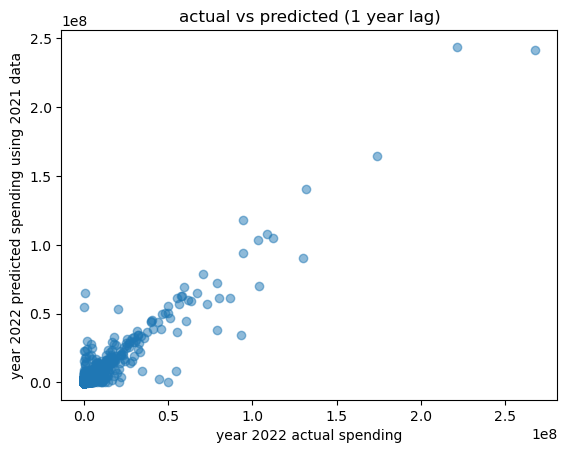

In [27]:
X_train = temp[temp['current_year']<2022][feature_cols]
X_val = temp[temp['current_year']==2022][feature_cols]

y_train = temp[temp['current_year']<2022]['Tot_Mdcr_Pymt_Amt_current']
y_val = temp[temp['current_year']==2022]['Tot_Mdcr_Pymt_Amt_current']

LR = sm.OLS(y_train,X_train).fit()
y_pred = LR.predict(X_val)

print('mlr = ', mean_log_ratio(y_val,y_pred))
print('mape = ', mape(y_val,y_pred))
print(LR.summary())

plt.scatter(y_val,y_pred,alpha=0.5)
plt.xlabel('year 2022 actual spending')
plt.ylabel('year 2022 predicted spending using 2021 data')
plt.title('actual vs predicted (1 year lag)')

## Try interaction

In [29]:
interaction_cols = [c for c in temp.columns.tolist() if 'Tot_Risk' in c and c!='Tot_Risk']

temp2 = temp.copy()

for c in interaction_cols:
    temp2[c] = temp2['Tot_Risk']*temp2[c]

In [30]:
feature_cols = [c for c in temp.columns if c not in ['Rndrng_NPI','Tot_Mdcr_Pymt_Amt_current','Tot_HCPCS_Cds','Tot_Risk']]

In [31]:
walkforward_LR(feature_cols,temp2,'Tot_Mdcr_Pymt_Amt_current')

,type,features,num_features,mlr_2018,mape_2018,R2_2018,mlr_2019,mape_2019,R2_2019,mlr_2020,mape_2020,R2_2020,mlr_2021,mape_2021,R2_2021,mlr_2022,mape_2022,R2_2022,mlr,mape,R2
0,LR,feature_cols,55,0.614765,1.599816,0.913506,0.613848,2.335314,0.862576,0.629504,1.385044,0.888515,2.551058,1.133876,0.859361,0.593929,1.834782,0.896014,1.000621,1.657766,0.883994


In [237]:
walkforward_LR([c for c in feature_cols if c!='Bene_Avg_Risk_Scre'],temp2,'Tot_Mdcr_Pymt_Amt_current')

,type,features,num_features,mlr_2018,mape_2018,R2_2018,mlr_2019,mape_2019,R2_2019,mlr_2020,mape_2020,R2_2020,mlr_2021,mape_2021,R2_2021,mlr_2022,mape_2022,R2_2022,mlr,mape,R2
0,LR,feature_cols,54,-0.569741,1.50339,0.912443,-0.345817,1.449248,0.863772,0.193467,1.313051,0.89053,-2.595743,1.369098,0.858411,0.331717,2.387779,0.900898,-0.597223,1.604513,0.885211


mlr =  0.6009924199666562
mape =  1.926452342039919
                                OLS Regression Results                               
Dep. Variable:     Tot_Mdcr_Pymt_Amt_current   R-squared:                       0.893
Model:                                   OLS   Adj. R-squared:                  0.893
Method:                        Least Squares   F-statistic:                 1.479e+06
Date:                       Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                               09:35:28   Log-Likelihood:            -1.0820e+08
No. Observations:                    7956527   AIC:                         2.164e+08
Df Residuals:                        7956481   BIC:                         2.164e+08
Df Model:                                 45                                         
Covariance Type:                   nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025

Text(0.5, 1.0, 'actual vs predicted (1 year lag)')

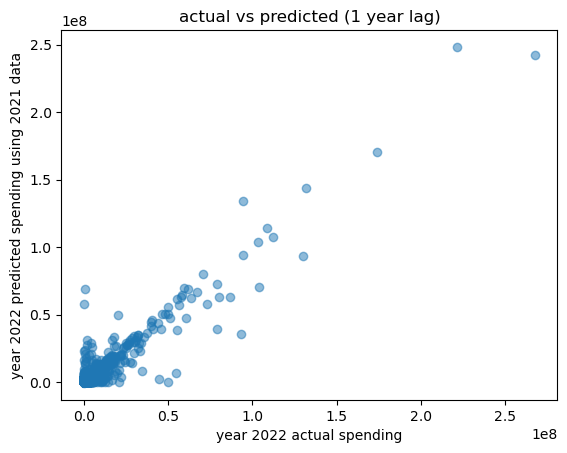

In [32]:
X_train = temp2[temp2['current_year']<2022][[c for c in feature_cols if c!='Bene_Avg_Risk_Scre']]
X_val = temp2[temp2['current_year']==2022][[c for c in feature_cols if c!='Bene_Avg_Risk_Scre']]

y_train = temp2[temp2['current_year']<2022]['Tot_Mdcr_Pymt_Amt_current']
y_val = temp2[temp2['current_year']==2022]['Tot_Mdcr_Pymt_Amt_current']

LR = sm.OLS(y_train,X_train).fit()
y_pred = LR.predict(X_val)

print('mlr = ', mean_log_ratio(y_val,y_pred))
print('mape = ', mape(y_val,y_pred))
print(LR.summary())

plt.scatter(y_val,y_pred,alpha=0.5)
plt.xlabel('year 2022 actual spending')
plt.ylabel('year 2022 predicted spending using 2021 data')
plt.title('actual vs predicted (1 year lag)')

# try Log payment

In [233]:
log_cols = ['Tot_HCPCS_Cds', 'Tot_Benes', 'Tot_Srvcs', 'Tot_Sbmtd_Chrg', 'Tot_Mdcr_Alowd_Amt', 'Tot_Mdcr_Pymt_Amt','Tot_Mdcr_Pymt_Amt_current','Tot_Risk']

temp3=temp.copy()

for c in log_cols:
    temp3[c] = temp3[c].apply(lambda x:x if x>=1 else 1)
    temp3[f'Log_{c}'] = np.log(temp2[c])

temp3.columns

Index(['Rndrng_NPI', 'Tot_HCPCS_Cds', 'Tot_Benes', 'Tot_Srvcs',
       'Tot_Sbmtd_Chrg', 'Tot_Mdcr_Alowd_Amt', 'Tot_Mdcr_Pymt_Amt',
       'Bene_Avg_Age', 'Bene_Avg_Risk_Scre', 'pca_1', 'Tot_Risk',
       'Tot_Mdcr_Pymt_Amt_current', 'current_year', 'Is_Covid', 'Cd_I', 'Cd_O',
       'Type_PrimaryCare', 'Type_LabPathology', 'Type_Anesthesia',
       'Type_OBGYN', 'Type_SurgeryOther', 'Type_CardioVascularSurgery',
       'Type_APP', 'Type_Cardiology', 'Type_MedicalSpecialtyOther',
       'Type_RehabTherapy', 'Type_FacilitySupplierProgram',
       'Type_OncologyHeme', 'Type_RadiologyImaging', 'Type_AcuteCare',
       'Type_BehavioralHealth', 'Type_VisionHearing', 'Type_PharmacyNutrition',
       'Type_UnknownOther', 'Ind_Y', 'Ind_N', 'APP_Tot_Risk_2',
       'APP_Tot_Risk_1', 'APP_Tot_Risk_0', 'PrimaryCare_Tot_Risk_0',
       'PrimaryCare_Tot_Risk_2', 'PrimaryCare_Tot_Risk_1',
       'MedicalSpecialtyOther_Tot_Risk_2', 'MedicalSpecialtyOther_Tot_Risk_0',
       'MedicalSpecialtyOther_Tot